<a href="https://colab.research.google.com/github/joschkawiegleb/joschkawiegleb.github.io/blob/master/20260804_Trailcam_Wiegleb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/YOUR_REPO/blob/main/YOUR_NOTEBOOK.ipynb)

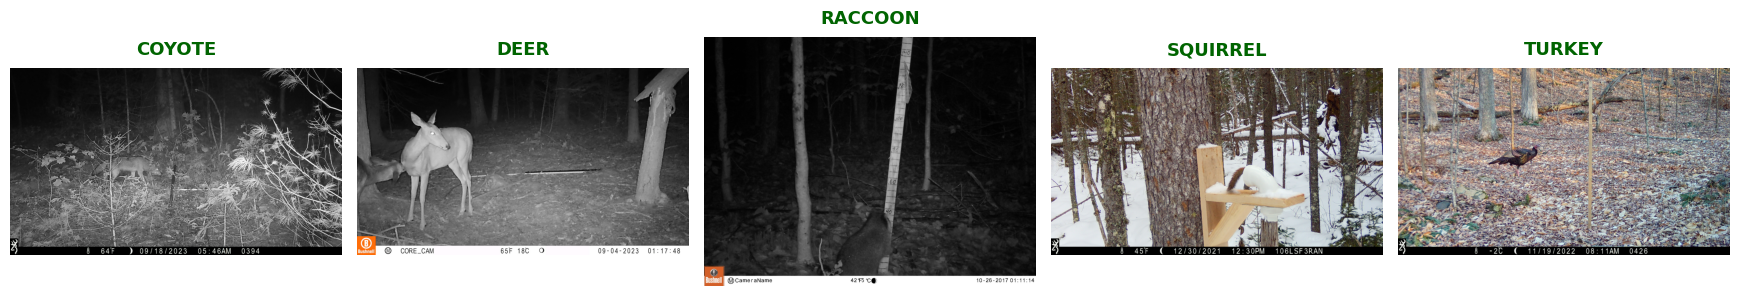
#Automated Wildlife Identification: AI & Computer Vision in Ecology

Welcome! In modern ecological field studies, motion-activated camera traps are one of our most powerful tools for monitoring animal populations, behavior, and biodiversity. However, camera traps routinely capture thousands of images—ranging from target wildlife to blowing leaves and livestock. Manually sorting and identifying every photo by hand takes hundreds of hours of research time.

In this session, you will explore how Convolutional Neural Networks (CNNs) (a type of artificial intelligence built for visual processing) can automatically identify wildlife species captured on trail cameras. No prior programming experience is required. You will run pre-written blocks of code (called "cells") step-by-step to train, evaluate, and test your own wildlife classification model.

A notebook from Joschka Wiegleb.

#Learning Targets

By completing this exercise, you will be able to:

1. Understand AI in Conservation: Explain how computer vision models are used to accelerate wildlife monitoring and biodiversity assessments.

2. Grasp Data Augmentation: Recognize how synthetic variations in lighting, angle, and framing help machine learning models adapt to changing real-world forest environments.

3. Evaluate Neural Network Performance: Interpret a Confusion Matrix, accuracy metrics, and confidence scores to identify which species your model accurately distinguishes and which it confuses.

4. Test Model Generalizability: Apply your trained network to new, unstudied trail camera images to test how well the model translates from training data to real-world field conditions.

#Project Outline

We will walk through the complete machine learning workflow used by wildlife ecologists:



##  Cell 1: System Setup

Connect to Google's GPU (Graphics Processing Unit) servers to accelerate our computational processing.

##   Cell 2: Data Retrieval

Download research-grade, open-source photos of local regional fauna (White-tailed Deer, Raccoon, Coyote, Wild Turkey, and Eastern Gray Squirrel) via the iNaturalist API.

##   Cell 3: Data Augmentation & Batching

Apply simulated environmental variations (lighting shifts, tree sways, camera tilts) to expand our dataset and prevent the model from simply memorizing backgrounds.

##   Cell 4: Neural Network Architecture

Load a proven image-recognition network (ResNet-18) and configure it specifically for our target wildlife species using Transfer Learning.

##   Cell 5: Model Training

Pass our images through the neural network over multiple iterations (epochs) so it learns key visual features (body shapes, fur textures, ear structures).

##   Cell 6 & 6B: Performance Validation & Single-Image Inspection

Generate a heatmap report (Confusion Matrix) showing overall accuracy, then interactively select individual animal photos to check predictions and confidence scores.

##   Cell 7: Field Testing (Your Own Trailcam Photos)

Upload custom camera trap photos from your own backyard or field sites to see how accurately your trained model performs on completely unseen data!

##   Cell 8: Real world example

Download a mixed set of a thousand images and use the trained network for automated screening and spatial (global) plotting of the animal records.

## Tip for Google Colab Beginners:

To run a code cell, click on the Play button ▶ on the left side of the cell, or click inside the cell and press Shift + Enter on your keyboard. Execute the cells sequentially from top to bottom!

In [ ]:
# ==============================================================================
# CELL 1: SETUP AND ENVIRONMENT CONFIGURATION
# ==============================================================================
# In this cell, we import all necessary libraries and check for GPU acceleration.
# Go to: Runtime -> Change runtime type -> T4 GPU.

import os
import urllib.request
import zipfile
import imghdr
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Configure hardware acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cpu':
    print("⚠️ WARNING: GPU is not enabled. Go to 'Runtime' -> 'Change runtime type' and select 'T4 GPU'!")
else:
    print("🚀 GPU is active and ready to train!")

## Cell 2: Retrieving Real Wildlife Data (Choose Your Dataset Path)

Before training our neural network, we need high-quality, verified ecological data. In this notebook, you have **two dataset options** to choose from.

Select and run **either Cell 2a OR Cell 2b** below:

---

### Option A: Cell 2a — iNaturalist Citizen Science Data
* **Data Source:** Community science observations shot by citizens on personal cameras and smartphones.
* **Why Choose This Path?** This option allows you to conduct a **Global Species Distribution Analysis** mapping worldwide observations later in cell 8.
* **What Happens:** Python sends an automated request to the iNaturalist API to retrieve verified, research-grade photos for 5 regional species.

---

### Option B: Cell 2b — AMMonitor Trail Camera Dataset
* **Data Source:** Motion-activated forest camera traps (trail cams) hosted on LILA BC.
* **Why Choose This Path?** This option allows you to evaluate model performance on **Local Camera Trap Field Deployments** (handling fixed forest backgrounds, night shots, and motion blur) later in cell 7.
* **What Happens:** Python streams trail camera photographs directly from public S3 cloud storage for the 5 target species.

---

### How Both Options Organize Your Data

Regardless of whether you run **Cell 2a** or **Cell 2b**, the script downloads photos for the same 5 target species (*White-tailed Deer, Raccoon, Coyote, Wild Turkey, and Eastern Gray Squirrel*) and automatically structures them into two pools:

* **Training Set (`train` — 75% of images):** The "textbook" images used by the neural network during training to learn anatomical features, fur patterns, and body shapes.
* **Validation Set (`val` — 25% of images):** A separate pool of images the network never sees during training. This acts as a practice exam to check how accurately the model generalizes to new, unseen photos.

## Note:

If you want to try another data set, it is required to restart the runtime (Runtime > Restart Session) and begin with cell 1 again.

## Student Action:

Click the Play button ▶ on the left side of Cell 2a or 2b below. You will see progress messages pop up as photos download for each species!

In [ ]:
# ==============================================================================
# CELL 2a: REAL WILDLIFE DATASET (DOUBLED SAMPLE SIZE via iNaturalist API)
# ==============================================================================
# Fetches 30 training images and 10 validation images per species (200 total images).
# Images stream directly from public AWS S3 buckets.

import os
import json
import urllib.request
import urllib.parse

# Local Eastern NA species mapped to scientific names for exact API querying
species_map = {
    'deer': 'Odocoileus virginianus',       # White-tailed Deer
    'raccoon': 'Procyon lotor',             # Raccoon
    'coyote': 'Canis latrans',              # Coyote
    'turkey': 'Meleagris gallopavo',        # Wild Turkey
    'squirrel': 'Sciurus carolinensis'      # Eastern Gray Squirrel
}

# 1. Create local train/val directory structure
for split in ['train', 'val']:
    for cls_name in species_map.keys():
        os.makedirs(f'wildlife_data/{split}/{cls_name}', exist_ok=True)

headers = {'User-Agent': 'ColabWildlifeEducation/1.0 (educational student project)'}

print("Fetching doubled wildlife observations from iNaturalist Open Data API...\n")

total_downloaded = 0

for cls_name, taxon_name in species_map.items():
    # Fetching up to 60 observations to guarantee 40 unique photos
    query_url = f"https://api.inaturalist.org/v1/observations?taxon_name={urllib.parse.quote(taxon_name)}&quality_grade=research&photos=true&per_page=60"

    try:
        req = urllib.request.Request(query_url, headers=headers)
        with urllib.request.urlopen(req) as response:
            data = json.loads(response.read().decode('utf-8'))

        photos = []
        for obs in data.get('results', []):
            for p in obs.get('photos', []):
                img_url = p.get('url', '')
                if img_url:
                    # Convert thumbnail 'square' URL to 'medium' (500px resolution)
                    medium_url = img_url.replace('/square.', '/medium.').replace('/square.jpg', '/medium.jpg')
                    photos.append(medium_url)

        # Doubled split: 30 training images and 10 validation images per species
        train_urls = photos[:30]
        val_urls = photos[30:40]

        counts = {'train': 0, 'val': 0}
        for split, url_list in [('train', train_urls), ('val', val_urls)]:
            for idx, img_url in enumerate(url_list, 1):
                save_path = f"wildlife_data/{split}/{cls_name}/{cls_name}_{idx}.jpg"
                try:
                    img_req = urllib.request.Request(img_url, headers=headers)
                    with urllib.request.urlopen(img_req) as img_resp, open(save_path, 'wb') as f:
                        f.write(img_resp.read())
                    counts[split] += 1
                    total_downloaded += 1
                except Exception:
                    pass  # Skip individual download glitches

        print(f" ├── {cls_name.capitalize():<10} Downloaded {counts['train']} train / {counts['val']} val images")

    except Exception as e:
        print(f" ❌ Could not fetch query for {cls_name}: {e}")

print(f"\n✅ Dataset Ready! Retrieved {total_downloaded} real wildlife images.")
print("📁 Proceed to Cell 3 (DataLoaders) and Cell 4 (ResNet Training)!")

In [ ]:
# ==============================================================================
# CELL 2b: AMMONITOR DATASET DOWNLOAD (FROM LILA BC — REAL METADATA-DRIVEN VERSION)
# ==============================================================================
# LILA doesn't expose predictable per-species filenames. You have to download
# the dataset's COCO-Camera-Traps metadata (one JSON describing every image),
# filter it locally for the species you want, THEN download just those images.

import os, json, zipfile, random, urllib.request
from concurrent.futures import ThreadPoolExecutor, as_completed

random.seed(0)

METADATA_URL = "https://lilawildlife.blob.core.windows.net/lila-wildlife/ammonitor-camera-traps/ammonitor-camera-traps.zip"
IMAGE_BASE   = "https://storage.googleapis.com/public-datasets-lila/ammonitor-camera-traps"

# Requested species -> substring(s) to match against LILA's category names
# (LILA uses common names like "white-tailed deer", "wild turkey", "eastern gray squirrel")
species_map = {
    'deer':     ['deer'],
    'raccoon':  ['raccoon'],
    'coyote':   ['coyote'],
    'turkey':   ['turkey'],
    'squirrel': ['squirrel'],
}

N_TRAIN, N_VAL = 30, 10

# 1. Create directory structure
for split in ['train', 'val']:
    for cls in species_map:
        os.makedirs(f'wildlife_data/{split}/{cls}', exist_ok=True)

# 2. Download + unzip metadata (only once)
if not os.path.exists('ammonitor-camera-traps.json'):
    print("Downloading metadata (this file can be large, please wait)...")
    urllib.request.urlretrieve(METADATA_URL, 'ammonitor-camera-traps.zip')
    with zipfile.ZipFile('ammonitor-camera-traps.zip') as z:
        json_name = [n for n in z.namelist() if n.endswith('.json')][0]
        z.extract(json_name, '.')
        os.rename(json_name, 'ammonitor-camera-traps.json')
    print("Metadata ready.")

print("Loading metadata JSON (large — may take a minute)...")
with open('ammonitor-camera-traps.json') as f:
    data = json.load(f)

categories = {c['id']: c['name'].lower() for c in data['categories']}
images_by_id = {im['id']: im for im in data['images']}

# 3. Match categories to our requested species
selected_cat_ids = {}  # species -> set of matching category ids
for species, keywords in species_map.items():
    matches = {cid for cid, name in categories.items()
               if any(kw in name for kw in keywords)}
    selected_cat_ids[species] = matches
    matched_names = [categories[c] for c in matches]
    print(f"'{species}' matched categories: {matched_names or 'NONE FOUND'}")

# 4. Collect image file_names per species from annotations
species_images = {s: set() for s in species_map}
for ann in data['annotations']:
    for species, cat_ids in selected_cat_ids.items():
        if ann['category_id'] in cat_ids:
            img = images_by_id.get(ann['image_id'])
            if img:
                species_images[species].add(img['file_name'])

# 5. Sample and download
def download_one(url, save_path):
    try:
        urllib.request.urlretrieve(url, save_path)
        return True
    except Exception:
        return False

total_downloaded = 0
for species, filenames in species_images.items():
    filenames = list(filenames)
    random.shuffle(filenames)
    available = len(filenames)
    need = N_TRAIN + N_VAL
    if available < need:
        print(f"⚠️  Only {available} images found for '{species}' (wanted {need})")
    train_files = filenames[:N_TRAIN]
    val_files   = filenames[N_TRAIN:N_TRAIN + N_VAL]

    counts = {'train': 0, 'val': 0}
    with ThreadPoolExecutor(max_workers=8) as ex:
        futures = {}
        for split, files in [('train', train_files), ('val', val_files)]:
            for idx, fname in enumerate(files, 1):
                url = f"{IMAGE_BASE}/{fname}"
                save_path = f"wildlife_data/{split}/{species}/{species}_{idx}.jpg"
                futures[ex.submit(download_one, url, save_path)] = split
        for fut in as_completed(futures):
            if fut.result():
                counts[futures[fut]] += 1
                total_downloaded += 1

    print(f" ├── {species.capitalize():<10} Downloaded {counts['train']} train / {counts['val']} val images")

print(f"\n✅ AMMonitor Dataset Ready! Retrieved {total_downloaded} camera trap images from LILA BC.")
print("📁 Proceed to Cell 3 (DataLoaders) and Cell 4 (ResNet Training)!")

## Cell 3: Data Augmentation & Dataset Expansion

In the field, trail camera conditions are never identical. Light shifts as clouds pass, wind tilts the camera on a tree trunk, and an animal might walk right up to the lens or stand far in the background.

If we only train a neural network on static, unvarying photos, it might accidentally memorize specific background trees or rocks rather than learning what an animal actually looks like. In this cell, we use a computer vision technique called Data Augmentation to solve this problem.

What Happens When You Run This Cell?

1. Environmental Simulation (Augmentation):

   Every time an image is loaded into the model, PyTorch automatically applies slight random modifications:

   * Camera Tilts: Rotates images up to 20° to simulate swaying trees or angled mounts.

   * Distance Shifts: Randomly crops and zooms to simulate animals standing close or far away.

   * Lighting Shifts: Adjusts brightness, contrast, and shadow levels to mimic full sun versus overcast days.

   * Mirroring: Flips images horizontally so the model learns animals facing both left and right.

2. Dataset Multiplication (3x Expansion):

   Rather than downloading hundreds of extra files, we tell PyTorch to create 3 random variations of every training image during each training cycle. This expands our 150 base training images into 450 unique training variations, making our model significantly more robust.

3. Batching for the GPU:

   Groups images into batches of 32 so Google's server graphics card (GPU) can process them efficiently in parallel.

## Student Action:

Click the Play button ▶ on Cell 3 below. You will see a summary output confirming your total training samples and target species!

In [ ]:
# ==============================================================================
# CELL 3: MULTIPLIED DATA AUGMENTATION & PYTORCH DATALOADERS
# ==============================================================================

import os
import shutil
import torch
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms

# 1. Clean hidden Colab checkpoint folders that break ImageFolder
data_dir = 'wildlife_data'
for root, dirs, files in os.walk(data_dir):
    for d in dirs:
        if d == '.ipynb_checkpoints':
            shutil.rmtree(os.path.join(root, d))

# 2. Rich Data Augmentation for Wildlife Photos
# Adds random horizontal flips, tilts, zooms, and lighting variations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),                            # Tilted cameras on trees
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),             # Simulates animals at different distances
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2), # Day/night & cloud shadow changes
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Define data_transforms dictionary for consistent access
data_transforms = {
    'train': train_transforms,
    'val': val_transforms
}

# 3. Base Training & Validation Datasets
base_train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), val_transforms)

# 4. MULTIPLY THE TRAINING DATASET SIZE (e.g., 3x factor)
# PyTorch generates a fresh random augmentation every time an image index is sampled!
AUGMENTATION_FACTOR = 3  # Expands training iterations 3-fold per epoch
train_dataset = ConcatDataset([base_train_dataset] * AUGMENTATION_FACTOR)

# DataLoaders
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2),
    'val': DataLoader(val_dataset, batch_size=32, shuffle=True, num_workers=2)
}

dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}
class_names = base_train_dataset.classes

print(f"✅ DataLoaders initialized with {AUGMENTATION_FACTOR}x Data Augmentation!")
print(f" ├── Base Unique Training Images:  {len(base_train_dataset)}")
print(f" ├── Augmented Samples per Epoch:  {dataset_sizes['train']}")
print(f" ├── Validation Images:            {dataset_sizes['val']}")
print(f" └── Target Species:               {class_names}")

## Cell 4: Neural Network Architecture & Transfer Learning

Building an artificial intelligence model from scratch requires millions of images and weeks of supercomputing time. Instead, professional ecologists use a powerful technique called Transfer Learning.

Transfer learning takes a pre-trained neural network—a model that has already spent hundreds of hours learning basic visual features like edges, shadows, fur textures, and animal shapes—and adapts it specifically to our local wildlife project.

What Happens When You Run This Cell?

1. Loading ResNet-18:

   We import ResNet-18, a famous 18-layer Convolutional Neural Network (CNN) known for being both fast and highly accurate at image recognition.

2. Freezing Early Layers:

   We "freeze" the network's early feature-extraction layers. This locks in its existing knowledge about basic visual patterns (like outlines and textures) so we don't erase them or waste computational time retraining them.

3. Customizing the Classification Head:

   We replace the network's final output layer with a custom classification head designed specifically for our 5 local species:

   * White-tailed Deer

   * Raccoon

   * Coyote

   * Wild Turkey

   * Eastern Gray Squirrel

4. Configuring the Learning System:

   We set up a Loss Function (which measures how wrong a prediction is) and an Optimizer (which makes subtle mathematical adjustments to improve accuracy over time).

## Student Action:

Click the Play button ▶ on Cell 4 below. A message will appear confirming that ResNet-18 has been modified and loaded into memory!

In [ ]:
# ==============================================================================
# CELL 4: THE NEURAL NETWORK (TRANSFER LEARNING)
# ==============================================================================
# We import ResNet-18. We keep its pre-trained features intact (frozen)
# and replace only the final output layer to fit our specific species.

print("Initializing ResNet-18 backbone...")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze pre-trained convolutional layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer with our output head size
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))

# Send model to CPU or GPU
model = model.to(device)

criterion = nn.CrossEntropyLoss()
# We only pass model.fc parameters to optimizer so we don't accidentally update frozen layers
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("CNN modified and successfully loaded into memory!")

## Cell 5: Training the Neural Network

Now comes the exciting part: actually training our model! In this step, the neural network examines our augmented wildlife photos, makes predictions, evaluates its own mistakes, and adjusts its internal settings to get better over time.

##Key Concepts to Watch For

* Epoch: A single complete pass through the entire training dataset. We will train for 5 epochs.

* Loss (Error Score): A mathematical score representing how wrong or uncertain the model's predictions are. Lower is better (we want this number to drop toward 0).

* Accuracy: The percentage of images the model identifies correctly. Higher is better (we want this number to rise toward 1.00 or 100%).

## What Happens When You Run This Cell?

During each epoch, the code runs two distinct phases:

1. Training Phase (TRAIN):

   The network looks at batches of training images, guesses the species, compares its guesses to the real labels, and updates its weights to improve.

2. Validation Phase (VAL):

   The network is tested on the separate validation images—photos it has never seen before. This tells us if the model is truly learning general animal features rather than just memorizing the training photos.

## Student Action:

Click the Play button ▶ on Cell 5 below. Watch how the Loss decreases and the Accuracy increases with each passing epoch! (On Google Colab's GPU, this will take less than 1 minute). You can also run different runs with varied epoch number and see how this effects the training process.

In [ ]:
# ==============================================================================
# CELL 5A: THE TRAINING LOOP & OVERFITTING VISUALIZATION
# ==============================================================================
# We train our top layer for 60 epochs while tracking loss and accuracy metrics
# to pinpoint the exact moment the model starts overfitting.

import matplotlib.pyplot as plt

def train_model(model, criterion, optimizer, num_epochs=60):
    # Dictionary to record performance metrics at each epoch
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch + 1}/{num_epochs}')
        print('=' * 25)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = (running_corrects.double() / dataset_sizes[phase]).item()

            # Record history metrics
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            print(f'{phase.upper():<5} Loss: {epoch_loss:.4f}  |  Accuracy: {epoch_acc:.4%}')

    # ==============================================================================
    # PLOTTING METRICS ACROSS EPOCHS
    # ==============================================================================
    epochs_range = range(1, num_epochs + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Plot Loss Curves
    ax1.plot(epochs_range, history['train_loss'], label='Training Loss (Blue)', color='navy', linewidth=2)
    ax1.plot(epochs_range, history['val_loss'], label='Validation Loss (Red)', color='crimson', linewidth=2, linestyle='--')
    ax1.set_title('Loss Curves (Error Rate)', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Loss (Lower is better)', fontsize=11)
    ax1.legend(fontsize=10)
    ax1.grid(True, linestyle=':', alpha=0.6)

    # 2. Plot Accuracy Curves
    ax2.plot(epochs_range, [acc * 100 for acc in history['train_acc']], label='Training Accuracy (Blue)', color='navy', linewidth=2)
    ax2.plot(epochs_range, [acc * 100 for acc in history['val_acc']], label='Validation Accuracy (Red)', color='crimson', linewidth=2, linestyle='--')
    ax2.set_title('Accuracy Curves (% Correct)', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('Accuracy % (Higher is better)', fontsize=11)
    ax2.legend(fontsize=10)
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle('Model Learning Performance Across 60 Epochs', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return model, history

# Begin training
trained_model, history = train_model(model, criterion, optimizer, num_epochs=60)

## Student Reading Guide: How to Spot Overfitting

When your training finishes, two graphs will render side-by-side. These graphs map out your model's learning journey across 60 epochs.

---

### 1. Understanding the Two Metrics

* **Loss (Left Graph):** Measures the model's total error rate. **Lower is better.**
* **Accuracy (Right Graph):** Measures the percentage of photos correctly identified. **Higher is better.**
* **Blue Line (Training):** Performance on photos the model is practicing with.
* **Red Dashed Line (Validation):** Performance on unseen photos.

#### Stage 1: Underfitting (Learning Phase)
* **What you see:** Both blue and red lines drop together on the Loss graph and rise together on the Accuracy graph.
* **Meaning:** The AI is actively discovering real visual patterns (such as fur patterns, ear shapes, and body silhouettes).

#### Stage 2: The Optimal "Sweet Spot"
* **What you see:** Validation loss (red line) reaches its lowest point on the graph.
* **Meaning:** This is the exact moment your model has learned maximum generalizable knowledge. Beyond this point, further training actually harms real-world performance!

#### Stage 3: Overfitting Zone (Background Memorization)
* **What you see:**
  * The blue line (Training) keeps getting better and better, eventually approaching near-zero loss or 100% accuracy.
  * The red line (Validation) stops improving, flattens out, or starts curving back upward.
  * A growing gap opens up between the blue and red lines.
* **Meaning:** The AI has run out of general animal features to learn. To get higher scores on its training set, it begins memorizing specific background details (like a bent branch or grass pattern in a specific coyote photo). When shown new validation photos with different backgrounds, it fails.


## Cell 5B: Inspecting Model Performance by Animal Request

While overall accuracy tells us how well the model performed across the entire dataset, ecologists often need to inspect individual predictions. Testing specific species helps us understand how the model makes decisions, where it feels confident, and where it makes mistakes.

In this cell, you can request any species from our dataset to see how the trained neural network evaluates an unseen photo of that animal.

## Key Concepts to Watch For

* True Label (Ground Truth): The actual verified species in the photograph.

* Predicted Label: The species that the trained neural network guessed.

* Confidence Score: A percentage ($0\%$ to $100\%$) indicating how certain the model is about its top guess based on probability calculations (Softmax).

* File Name & Path: The exact file reference listed below the plot, allowing you to trace back and inspect the original source file.

## What Happens When You Run This Cell?

1. Species Selection Prompt:

   The cell will ask you to type the name of an animal species (deer, raccoon, coyote, turkey, or squirrel).

2. Random Image Retrieval:

   Python pulls a random test photograph of that species from the validation folder—an image the network never saw during training.

3. Inference & Scoring:

   The image is passed through your trained model. The program compares the model's guess against the True Label and calculates the confidence percentage.

4. Visual Assessment:

   The image displays with a green header (✅ CORRECT) if the network guessed correctly, or a red header (❌ MISCLASSIFIED) if it made a mistake.

## Student Action:

1. Click the Play button ▶ on Cell 5B below.

2. Look below the code box for the text prompt, type a species name (e.g., deer or raccoon), and press Enter on your keyboard!

In [ ]:
# ==============================================================================
# CELL 5B: TEST A SPECIFIC ANIMAL BY REQUEST
# ==============================================================================
# Type or select an animal species to load a validation image.
# Displays Ground Truth, Model Prediction, Confidence Score, and File Path/Name!

import random
from PIL import Image

# 1. Prompt user for target species
print(f"Available species: {class_names}\n")
requested_species = input(f"Enter the animal you want to inspect ({'/'.join(class_names)}): ").strip().lower()

# Fallback validation if input isn't recognized
if requested_species not in class_names:
    print(f"⚠️ '{requested_species}' not found in dataset. Defaulting to '{class_names[0]}'.")
    requested_species = class_names[0]

# 2. Pick a random test image for that species from the validation set
val_folder = os.path.join('wildlife_data', 'val', requested_species)
available_images = [f for f in os.listdir(val_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

if not available_images:
    print(f"❌ No validation images found in {val_folder}!")
else:
    chosen_image_name = random.choice(available_images)
    image_path = os.path.join(val_folder, chosen_image_name)

    # Print file details directly to the console
    print(f"📄 File Name: {chosen_image_name}")
    print(f"📁 File Path: {image_path}\n")

    # 3. Load image and set Ground Truth (True Label)
    img = Image.open(image_path).convert('RGB')
    true_label = requested_species

    # 4. Preprocess and run CNN inference
    preprocess = data_transforms['val']
    img_tensor = preprocess(img).unsqueeze(0).to(device)

    trained_model.eval()
    with torch.no_grad():
        outputs = trained_model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, pred_idx = torch.max(probabilities, 0)

        predicted_label = class_names[pred_idx.item()]
        confidence_score = confidence.item() * 100.0

    # 5. Plot image with True Label, Prediction, Confidence Score, and File Info
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(img)
    ax.axis('off')

    # Green title if prediction matches True Label, Red if misclassified
    title_color = 'darkgreen' if predicted_label == true_label else 'darkred'
    status_icon = "✅ CORRECT" if predicted_label == true_label else "❌ MISCLASSIFIED"

    title_text = (
        f"{status_icon}\n"
        f"TRUE LABEL: {true_label.upper()}\n"
        f"PREDICTED: {predicted_label.upper()} ({confidence_score:.2f}% Confidence)"
    )
    ax.set_title(title_text, fontsize=13, color=title_color, fontweight='bold', pad=12)

    # Display File Name and File Path below the image
    file_info_text = f"File: {chosen_image_name}\nPath: {image_path}"
    fig.text(0.5, 0.02, file_info_text, ha='center', fontsize=9, color='gray', style='italic')

    plt.tight_layout()
    plt.show()

## Cell 6: Quantitative Validation & Confusion Matrix

Single-image tests give us a quick glimpse into model performance, but how do we evaluate our artificial intelligence across the entire dataset? In ecological research, understanding where and why a model makes errors is just as important as knowing its overall accuracy score.

In this cell, we run a full validation pass to generate a statistical performance report and a visual tool called a Confusion Matrix.

## Key Concepts to Watch For

   * Confusion Matrix: A grid that compares the True Species (rows) against the model's Predicted Species (columns).

      * Diagonal Line (Dark Blue): Correct predictions! High numbers along the diagonal mean the model accurately identified those species.

      * Off-Diagonal Cells: Errors. These show you exactly which species pair the model confuses (for example, mistaking a gray squirrel for a raccoon in dark foliage).

   * Precision: When the model claims an image contains a "Deer", how often is it actually a deer? (High precision means few false alarms).

   * Recall: Out of all the actual deer photos in our validation set, what percentage did the model successfully find? (High recall means few missed animals).

## What Happens When You Run This Cell?

1. Full Validation Pass: The trained network evaluates every single photo in the validation set.

2. Tabular Metrics Report: Prints a summary table showing Precision, Recall, and overall accuracy scores for each species.

3. Heatmap Visualization: Generates a color-coded confusion matrix so you can visually spot patterns in how your neural network distinguishes local wildlife.

## Student Action:

Click the Play button ▶ on Cell 6 below. Look at the darker blue squares on the grid—did your model struggle with any specific species pairs?

In [ ]:
# ==============================================================================
# CELL 6: QUANTITATIVE VALIDATION (METRICS & CONFUSION MATRIX)
# ==============================================================================
# Let's inspect our model scientifically. This generates precision/recall stats
# and prints a visual heatmap showing exactly what species confuse our network.

def run_advanced_validation(model, dataloader):
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # 1. Output tabular metrics
    print("\n" + "="*50)
    print("             CLASSIFICATION METRICS REPORT")
    print("="*50)
    print(classification_report(all_labels, all_preds, target_names=class_names))
    print("="*50)

    # 2. Build Confusion Matrix heatmap
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Species')
    plt.ylabel('Actual Species (Ground Truth)')
    plt.title('Validation Set Confusion Matrix')
    plt.show()

# Run calculations on validation split
run_advanced_validation(trained_model, dataloaders['val'])

## Student Guide: Reading the Confusion Matrix and Evaluation Metrics

When evaluating a wildlife classification AI, overall accuracy doesn't tell the entire story. In ecological research, **what kind of error** the model makes is often more important than the number of errors.

This guide breaks down how to interpret the confusion matrix heatmap and the classification metrics report generated in **Cell 6**.

---

### 1. How to Read the Confusion Matrix

The confusion matrix is a grid that cross-examines the ground truth against the model's predictions. Here is an example:

```text
                   PREDICTED SPECIES (Model Guess)
                   Coyote   Deer   Raccoon   Squirrel   Turkey
ACTUAL   Coyote   │   8   │  0   │   2    │    0     │    0   │
SPECIES  Deer     │   0   │ 10   │   0    │    0     │    0   │
(Ground  Raccoon  │   1   │  0   │   7    │    2     │    0   │
 Truth)  Squirrel │   0   │  0   │   1    │    9     │    0   │
         Turkey   │   0   │  0   │   0    │    0     │   10   │
```

### The 3 Rules for Reading the Grid:

* **Find the Diagonal (Dark Blue Squares = Hits):**  
  Look from the top-left corner down to the bottom-right corner. Numbers on this diagonal represent correct predictions where the actual species matches the model's guess.

* **Read Rows Horizontally for Ground Truth (Actual Animals):**  
  Pick a single row (e.g., **Actual Raccoon**). Following across the row shows what happened to all actual raccoon photos:
  * $7$ were correctly identified as Raccoons.
  * $1$ was wrongly misclassified as a Coyote.
  * $2$ were wrongly misclassified as Squirrels.

* **Read Columns Vertically for Model Predictions (Guesses):**  
  Pick a single column (e.g., **Predicted Coyote**). Looking down the column shows every photo the model claimed was a coyote:
  * $8$ were actual Coyotes (Correct).
  * $1$ was actually a Raccoon (False alarm).

---

### 2. Decoding the 4 Evaluation Metrics

```text
               precision    recall  f1-score   support

      coyote       0.89      0.80      0.84        10
        deer       1.00      1.00      1.00        10
     raccoon       0.70      0.70      0.70        10
    squirrel       0.82      0.90      0.86        10
      turkey       1.00      1.00      1.00        10
```

#### A. Accuracy: The Overall Score
* **Question it answers:** *"Out of all photos analyzed, what percentage did the AI get right?"*

$$\text{Accuracy} = \frac{\text{Total Correct Predictions}}{\text{Total Images Analyzed}}$$

* **Ecological Pitfall:** Accuracy can be misleading. If your dataset contains 90 deer photos and 10 coyote photos, a dumb model that guesses "Deer" 100% of the time will achieve **90% accuracy**, while completely missing every single coyote in the study!

#### B. Precision: The Reliability of Guesses
* **Question it answers:** *"When the AI labels an image as 'Coyote', how often is it actually a coyote?"*

$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$$

* **What low precision means:** High rate of **False Alarms**. If coyote precision is $0.50$ (50%), half of the images flagged as coyotes are actually other animals.
* **Field Impact:** Biologists waste hours manually sifting through flagged images to remove false positives.

---

#### C. Recall: Sensitivity & Completeness
* **Question it answers:** *"Out of all actual Coyotes present in the forest photos, what percentage did the AI manage to find?"*

$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$$

* **What low recall means:** High rate of **Missed Detections**. If coyote recall is $0.60$ (60%), the model missed 40% of the real coyotes present in the study.
* **Field Impact:** Underestimating animal populations or missing rare, endangered predators entirely.

---

#### D. F1-Score: The Harmonic Balance
* **Question it answers:** *"What is the overall balanced score between Precision and Recall?"*

Precision and Recall exist in a tug-of-war. If a model becomes overly aggressive, recall goes up but precision drops. The **F1-Score** uses a *harmonic mean* to penalize extreme imbalances:

$$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

* **Why Harmonic Mean instead of regular average?**  
  If Precision is $1.00$ (100%) and Recall is $0.00$ (0%), a standard average yields 50%. However, a model with 0% recall is useless in ecology. The harmonic mean yields an F1-Score of **$0.00$**, correctly reflecting failure.

---

### Metric Reference Table for Ecologists

| Metric | Focus Question | Goal | High Score Means... | Low Score Means... |
| :--- | :--- | :--- | :--- | :--- |
| **Precision** | Is the guess reliable? | Minimize False Alarms | Clean dataset with minimal false flags | Research time wasted checking bad guesses |
| **Recall** | Did we catch every individual? | Minimize Missed Animals | Comprehensive population counts | Missing rare or elusive wildlife |
| **F1-Score** | Is the model well-balanced? | Balance Both | High confidence for field deployment | Model leans heavily toward false alarms or missed detections |

## Cell 7: Field Testing (Classifying Your Own Trailcam Photos)

Congratulations! You have trained, evaluated, and inspected your neural network. Now comes the ultimate test of any ecological model: field testing.

In machine learning, testing a model on completely new data collected in different locations, under different lighting, or with different camera hardware is called testing for generalizability. In this final cell, you can upload your own camera trap photos (or an image downloaded from the web) to see how accurately your AI performs in the wild!

## Key Concepts to Reflect On

* Generalization: Can the model recognize a deer or raccoon when it appears against a background it has never seen during training?

* Background Bias: Neural networks sometimes rely on background cues (like specific tree trunks or grass types). If your image has a vastly different background, does the model still focus on the animal?

* Out-of-Distribution Inputs: What happens if you upload a photo of an animal not included in our 5 target species (like a black bear, house cat, or human)? Hint: Remember that the Softmax function forces the network to choose from our 5 target classes, even if the real object isn't one of them!

## What Happens When You Run This Cell?

1. File Upload Prompt:

   Colab will display a Choose Files button allowing you to select a JPEG or PNG photo from your computer.

2. Automated Safety & Format Check:

   The script automatically verifies that your file is an actual image (under 15MB) to prevent errors before feeding it to PyTorch.

3. Preprocessing & Neural Inference:

   Your custom image is scaled, normalized, and passed through your trained ResNet-18 model.

4. Prediction & Confidence Output:

   The cell renders your photo with a top header displaying the predicted species name and the model's calculated confidence score.

## Student Action:

1. Click the Play button ▶ on Cell 7 below.

2. Click the Choose Files button that appears below the code box.

3. Select a trail camera photo from your computer and watch your AI classify it in real time!

In [ ]:
# ==============================================================================
# CELL 7: LIVE INFERENCE (STUDENTS UPLOAD THEIR OWN PHOTOS)
# ==============================================================================
# Students upload a JPEG/PNG photo from their local trail cameras.
# The program validates the input safety and runs the trained CNN to make a prediction.

import os
from google.colab import files
from PIL import Image

def detect_image_type(path):
    """Lightweight, non-deprecated replacement for imghdr.what()."""
    try:
        with Image.open(path) as img:
            return img.format.lower()  # e.g. 'jpeg', 'png'
    except Exception:
        return None

print("Please select your trailcam file to upload (JPEG or PNG under 15MB):")
uploaded = files.upload()

if not uploaded:
    print("⚠️ No file uploaded. Execution stopped.")

for filename, file_content in uploaded.items():
    # File Size Validation
    file_size_mb = len(file_content) / (1024 * 1024)
    if file_size_mb > 15:
        print(f"❌ Error: '{filename}' is too large ({file_size_mb:.1f}MB). Please compress and re-upload.")
        continue

    # File Type Validation
    temp_path = f"temp_{filename}"
    with open(temp_path, "wb") as f:
        f.write(file_content)

    image_type = detect_image_type(temp_path)
    if image_type not in ['jpeg', 'png']:
        print(f"❌ Error: '{filename}' has invalid image headers (detected: {image_type or 'Unknown'}).")
        os.remove(temp_path)
        continue

    print(f"✅ Image validated: {filename} ({image_type.upper()}). Processing prediction...")

    try:
        # Load and convert image to RGB
        img = Image.open(temp_path).convert('RGB')

        # Preprocess identically to validation parameters
        preprocess = data_transforms['val']
        img_tensor = preprocess(img).unsqueeze(0).to(device)

        # Inference Step
        trained_model.eval()
        with torch.no_grad():
            outputs = trained_model(img_tensor)
            probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
            confidence, preds = torch.max(probabilities, 0)

        # Display Resulting Image and Metadata
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis('off')

        prediction_text = f"Predicted: {class_names[preds.item()].upper()} ({confidence.item()*100:.2f}%)"
        plt.title(prediction_text, fontsize=14, color='darkgreen', fontweight='bold')
        plt.show()

    except Exception as e:
        print(f"❌ Critical error parsing image pipeline: {e}")
    finally:
        # Cleanup temporary filesystem buffer
        if os.path.exists(temp_path):
            os.remove(temp_path)

## Conclusive Summary & Ecological Takeaways

Congratulations on completing your first automated wildlife identification workflow!

Through this exercise, you built, trained, evaluated, and field-tested a Convolutional Neural Network (CNN) capable of identifying local wildlife species from motion-activated camera traps.

## What You Accomplished Today

* Data Pipeline Construction: Downloaded research-grade ecological observations directly from iNaturalist to build a structured training and validation dataset.

* Applied Data Augmentation: Simulated changing field conditions (bright sunlight, heavy shadows, camera tilts, and distance variations) to prevent your model from over-memorizing static forest backgrounds.

* Leveraged Transfer Learning: Customized a pre-trained computer vision model (ResNet-18) to classify five key regional species: White-tailed Deer, Raccoon, Coyote, Wild Turkey, and Eastern Gray Squirrel.

* Evaluated Model Performance: Interpreted confidence scores, precision/recall metrics, and a visual Confusion Matrix to identify specific species pairs that challenge the network.

* Tested Field Generalizability: Deployed your trained network onto new, unseen camera trap images to see how artificial intelligence handles real-world field data.

## Core Machine Learning Insights for Conservation

1. Efficiency at Scale: Automated species identification dramatically reduces the manual effort required to process millions of trailcam photos, allowing conservationists to focus on population estimation, habitat management, and policy.

2. The "Background Trap": CNNs learn patterns wherever they can find them. Data augmentation forces the network to focus on key anatomical features (such as ear shape or body proportions) rather than relying on background foliage or soil textures.

3. Confidence Does Not Equal Truth: The Softmax function always forces probabilities across our known species list to total 100%. If an unlearned object (like a domestic dog, tractor, or human) appears on camera, the model will still assign high confidence to whichever of the 5 known species it resembles most closely.

4. Iterative Improvement: No AI model is 100% perfect on day one. Error analysis via confusion matrices shows researchers exactly which species need more training images or stronger data augmentation in the next iteration.

## Discussion Questions for Reflection

* Which species did your model classify with the highest accuracy, and why might its visual features be easier for the network to distinguish?

* Did your model struggle with any specific species pairs in the confusion matrix? How might seasonal shifts (such as winter snow vs. summer green foliage) impact model accuracy in the field?

* What steps would you take before deploying this model in a real conservation management project to handle "blank" images (triggered by wind) or unexpected species?

## Bonus task:

## Cell 8: Global Field Deployment, Excel Export & Geospatial Mapping

In real-world conservation, artificial intelligence models are deployed to process vast pipelines of geotagged field data. In this final cell, we transition from localized model testing to **macro-ecological deployment** by connecting directly to the public **iNaturalist API**.

This cell executes a complete end-to-end ecological data pipeline: querying live global observation records, running batch neural network predictions, exporting structured reporting tables, and mapping wildlife spatial distributions across the globe.

---

### What Happens When You Run This Cell?

1. **Taxon Resolution:** The script searches iNaturalist to resolve your model's 5 target species names into official scientific taxon IDs.
2. **Balanced Global Sampling:** The code fetches **1,000 real, research-grade, geotagged wildlife photos** from around the world.
   * **At least 50% of the photos** belong to your model's 5 target species.
   * **The remaining photos** consist of non-target species (e.g., wild boars, foxes, birds) to test how your model handles unexpected wildlife in the field.
3. **Automated Neural Inference:** Each downloaded image is preprocessed and evaluated by your trained PyTorch model to extract predicted species labels and confidence percentages.
4. **Excel Data Export:** All metadata—including observation IDs, timestamps, GPS coordinates, ground-truth scientific names, and AI predictions—is exported directly to an Excel file: `inaturalist_predictions_metadata.xlsx`.
5. **Per-Species World Scatter Maps:** Using Plotly Express, the cell renders **interactive global scatter maps** displaying the exact latitude and longitude for every detection point predicted for each species.

---

> **Student Action:**  
> 1. Click the **Play button ▶** on Cell 8 below.  
> 2. Wait for the live API query and batch inference to complete (this may take 2–3 minutes).  
> 3. Inspect the sample output table and hover over the interactive world map detection points!

In [ ]:
# ==============================================================================
# CELL 8 : iNaturalist-BASED DEPLOYMENT, EXCEL EXPORT & WORLD MAPS
# ==============================================================================
# Pulls real, geotagged wildlife photos from the public iNaturalist AP,
# runs the trained model on them, exports
# an Excel table, and plots ONE WORLD SCATTER MAP PER PREDICTED SPECIES
# showing real detection points (not a choropleth/heatmap).
#
# SAMPLING: at least 50% of the 1,000 sampled images must have a
# ground-truth iNaturalist taxon matching one of `class_names` (the model's
# known classes). If the live API can't supply enough open-geoprivacy,
# research-grade photos for those classes, this cell PRINTS A WARNING and
# proceeds with whatever real data it could get — it never pads the sample
# with fabricated records to hit the quota.

import os
import time
import json
import random
import urllib.request
import urllib.parse
from io import BytesIO

import pandas as pd
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import openpyxl
except ImportError:
    get_ipython().system('pip install openpyxl -q')
    import openpyxl

try:
    import plotly.express as px
except ImportError:
    get_ipython().system('pip install plotly -q')
    import plotly.express as px

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
TOTAL_SAMPLE_SIZE = 1000
MIN_TARGET_CLASS_FRACTION = 0.5                                   # required 50%
TARGET_CLASS_QUOTA = int(TOTAL_SAMPLE_SIZE * MIN_TARGET_CLASS_FRACTION)  # 500
INAT_BASE = "https://api.inaturalist.org/v1"
# iNaturalist asks API consumers to identify themselves and rate-limit
# themselves (no hard auth required for read-only access).
HEADERS = {'User-Agent': 'ColabWildlifeEducation/1.0 (contact: your_email@example.com)'}
REQUEST_DELAY_SEC = 1.0

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


def inat_get(endpoint, params):
    """GET helper against the iNaturalist API with basic error handling."""
    url = f"{INAT_BASE}/{endpoint}?{urllib.parse.urlencode(params)}"
    req = urllib.request.Request(url, headers=HEADERS)
    with urllib.request.urlopen(req, timeout=30) as resp:
        data = json.loads(resp.read().decode('utf-8'))
    time.sleep(REQUEST_DELAY_SEC)
    return data


def resolve_taxon(common_name):
    """Resolve a model class name (e.g. 'bobcat') to an iNaturalist taxon_id
    via the taxa autocomplete/search endpoint, so we query by ID rather than
    an ambiguous free-text name."""
    data = inat_get("taxa", {"q": common_name, "rank": "species", "per_page": 1})
    results = data.get("results", [])
    if not results:
        return None
    taxon = results[0]
    return {
        "taxon_id": taxon["id"],
        "scientific_name": taxon.get("name"),
        "common_name": taxon.get("preferred_common_name") or common_name
    }


def fetch_observations(taxon_id=None, n_needed=200, page_start=1, max_pages=5):
    """Fetch up to n_needed real, open-geoprivacy, research-grade, photographed
    observations, optionally filtered to a single taxon_id."""
    collected = []
    page = page_start
    while len(collected) < n_needed and page < page_start + max_pages:
        params = {
            "photos": "true",
            "geo": "true",
            "geoprivacy": "open",        # exact coordinates only, no obscured points
            "quality_grade": "research", # community-verified ID
            "per_page": min(200, n_needed - len(collected)),
            "page": page,
            "order_by": "id",
        }
        if taxon_id is not None:
            params["taxon_id"] = taxon_id

        try:
            data = inat_get("observations", params)
        except Exception:
            break

        results = data.get("results", [])
        if not results:
            break

        for obs in results:
            photos = obs.get("photos", [])
            location = obs.get("location")  # "lat,lng" string when geoprivacy=open
            if not photos or not location:
                continue
            try:
                lat_str, lon_str = location.split(",")
                lat, lon = float(lat_str), float(lon_str)
            except ValueError:
                continue

            photo_url = photos[0].get("url", "")
            # iNaturalist thumbnail URLs look like .../square.jpg — swap for a
            # much larger version so the model isn't fed a tiny thumbnail.
            large_url = photo_url.replace("square", "large") if photo_url else None
            if not large_url:
                continue

            taxon_info = obs.get("taxon") or {}
            collected.append({
                "observation_id": obs.get("id"),
                "image_url": large_url,
                "timestamp": obs.get("observed_on") or "unknown",
                "latitude": lat,
                "longitude": lon,
                "ground_truth": taxon_info.get("preferred_common_name")
                                 or taxon_info.get("name")
                                 or "Unknown"
            })
        page += 1

    return collected[:n_needed]


# ==============================================================================
# 1. RESOLVE MODEL CLASSES TO iNATURALIST TAXA
# ==============================================================================
print("🔎 Resolving model classes to iNaturalist taxa...")
resolved_taxa = {}
unresolved_classes = []

for cls in class_names:
    info = resolve_taxon(cls)
    if info:
        resolved_taxa[cls] = info
        print(f"  ✅ '{cls}' → {info['scientific_name']} (taxon_id={info['taxon_id']})")
    else:
        unresolved_classes.append(cls)
        print(f"  ⚠️ Could not resolve '{cls}' to an iNaturalist taxon — excluded "
              f"from guaranteed-quota sampling.")

if not resolved_taxa:
    raise RuntimeError("None of the model's class_names could be resolved to iNaturalist "
                        "taxa. Cannot proceed with quota-based sampling.")

# ==============================================================================
# 2. PULL REAL OBSERVATIONS — TARGET CLASSES FIRST (EXACT 500 QUOTA), THEN FILLER
# ==============================================================================
print(f"\n📡 Fetching real, geotagged iNaturalist observations "
      f"(target: ≥{TARGET_CLASS_QUOTA}/{TOTAL_SAMPLE_SIZE} from known classes)...")

# Split the 500-image quota evenly across resolved classes, distributing any
# remainder so the quotas SUM to exactly TARGET_CLASS_QUOTA (floor division
# alone would under-shoot the 50% requirement by construction).
n_classes = len(resolved_taxa)
base_quota, remainder = divmod(TARGET_CLASS_QUOTA, n_classes)
class_quotas = {
    cls: base_quota + (1 if i < remainder else 0)
    for i, cls in enumerate(resolved_taxa)
}

target_class_records = []
for cls, info in resolved_taxa.items():
    quota = class_quotas[cls]
    obs = fetch_observations(taxon_id=info["taxon_id"], n_needed=quota)
    print(f"  ├── {cls}: requested {quota}, got {len(obs)} real observations")
    target_class_records.extend(obs)

target_class_count = len(target_class_records)

# Fill remaining slots with real, non-target-class observations (a broad,
# unfiltered pull) to keep a realistic mixed evaluation set rather than only
# ever showing the model images it's expecting.
remaining_slots = TOTAL_SAMPLE_SIZE - target_class_count
filler_records = []
if remaining_slots > 0:
    print(f"\n📡 Fetching {remaining_slots} additional real observations "
          f"(mixed species) to fill out the 1,000-image sample...")
    filler_records = fetch_observations(taxon_id=None, n_needed=remaining_slots,
                                         page_start=random.randint(1, 50))

records = target_class_records + filler_records
random.shuffle(records)
records = records[:TOTAL_SAMPLE_SIZE]

# ==============================================================================
# 3. VERIFY THE 50% QUOTA — WARN INSTEAD OF FAKING IT IF UNACHIEVABLE
# ==============================================================================
achieved_fraction = target_class_count / TOTAL_SAMPLE_SIZE
quota_met = target_class_count >= TARGET_CLASS_QUOTA

print(f"\n📊 Sample composition: {target_class_count}/{TOTAL_SAMPLE_SIZE} images "
      f"({achieved_fraction:.1%}) are ground-truthed to the model's known classes.")

if not quota_met:
    print(
        "\n" + "=" * 78 +
        "\n⚠️  WARNING: Could not reach the required 50% known-class quota.\n" +
        f"    Needed ≥{TARGET_CLASS_QUOTA} images from {list(resolved_taxa.keys())}, "
        f"but iNaturalist's public API (open-geoprivacy, research-grade, "
        f"photographed observations) returned only {target_class_count} for this run.\n" +
        (f"    Classes with NO taxon match at all: {unresolved_classes}\n"
         if unresolved_classes else "") +
        "    Proceeding with the reduced/available sample below. Treat the "
        "per-species maps as illustrative, not statistically representative, "
        "until this is resolved — options: relax quality_grade to "
        "'needs_id,research', drop geoprivacy='open' (accepting obscured "
        "points), or raise max_pages per class.\n" + "=" * 78
    )

print(f"\n✅ Final sample size: {len(records)} real iNaturalist observations "
      f"({target_class_count} known-class, {len(records) - target_class_count} other species).")

# ==============================================================================
# 4. BATCH AI MODEL INFERENCE ON REAL iNATURALIST PHOTOS
# ==============================================================================
print("\n🧠 Running neural network predictions on real iNaturalist photos...")
trained_model.eval()

results_list = []
processed_count = 0
skipped_count = 0

for item in records:
    try:
        req = urllib.request.Request(item['image_url'], headers=HEADERS)
        with urllib.request.urlopen(req, timeout=10) as response:
            img_bytes = response.read()
            img = Image.open(BytesIO(img_bytes)).convert('RGB')

        input_tensor = inference_transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            output = trained_model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            conf, pred_idx = torch.max(probabilities, 1)
            predicted_class = class_names[pred_idx.item()]
            confidence_score = float(conf.item() * 100)

        results_list.append({
            'iNat_Observation_ID': item['observation_id'],
            'Timestamp': item['timestamp'],
            'Latitude': item['latitude'],
            'Longitude': item['longitude'],
            'Predicted_Species': predicted_class.capitalize(),
            'Confidence_Percent': round(confidence_score, 2),
            'Ground_Truth_Taxon': item['ground_truth'],
            'Image_URL': item['image_url']
        })

        processed_count += 1
        if processed_count % 100 == 0:
            print(f"  ├── Processed {processed_count}/{len(records)} photos...")

    except Exception:
        skipped_count += 1
        continue

print(f"✅ Completed AI inference on {len(results_list)} real iNaturalist images "
      f"({skipped_count} skipped due to download/decoding errors).")

if not results_list:
    raise RuntimeError("No images were successfully processed — check network access, "
                        "and print records[0] to confirm the response schema matches "
                        "what this script expects.")

# ==============================================================================
# 5. EXPORT TO EXCEL
# ==============================================================================
df_results = pd.DataFrame(results_list)
excel_filename = 'inaturalist_predictions_metadata.xlsx'
df_results.to_excel(excel_filename, index=False, engine='openpyxl')
print(f"💾 Results exported to Excel: '{excel_filename}'")
print("\n📋 Excel File Preview (First 5 Rows):")
display(df_results.head())

# ==============================================================================
# 6. ONE WORLD MAP PER PREDICTED SPECIES — DETECTION POINTS (NO HEATMAP)
# ==============================================================================
print("\n🗺️ Generating one world scatter map per predicted species ")

for species in sorted(df_results['Predicted_Species'].unique()):
    sp_df = df_results[df_results['Predicted_Species'] == species]

    fig = px.scatter_geo(
        sp_df,
        lat='Latitude',
        lon='Longitude',
        hover_name='Ground_Truth_Taxon',
        hover_data={'Confidence_Percent': True, 'Timestamp': True,
                     'Latitude': False, 'Longitude': False},
        projection='natural earth',
        title=f'iNaturalist: Real Detection Points Predicted as "{species}" (n={len(sp_df)})'
    )
    fig.update_traces(marker=dict(size=6, opacity=0.75, line=dict(width=0.5, color='black')))
    fig.update_layout(margin=dict(l=0, r=0, t=50, b=0))
    fig.show()



## Conclusive Reflection: Machine Learning in Global Ecology

Congratulations! You have successfully built, evaluated, and deployed an end-to-end computer vision workflow for wildlife conservation.

By running this scaled deployment cell, you have observed how automated image recognition bridges the gap between raw citizen-science data and actionable, spatial conservation intelligence.

---

### Key Takeaways from Your Global Deployment

1. **Transforming Raw Data into Spatial Datasets:**  
   Manual processing of 1,000 camera trap or citizen science photos would take hours of expert labor. Your network classified and organized these global records alongside their GPS coordinates in just a few minutes.

2. **The Closed-Set Assumption (Out-of-Distribution Inputs):**  
   Notice how your model behaves when presented with non-target species (the ~50% filler photos of animals it was never trained to recognize). Because the final Softmax layer forces probabilities across your 5 known classes to sum to 100%, the model will *always* assign a prediction to one of those 5 classes—even for a bear, bird, or human.

3. **Sampling & Geographic Bias:**  
   Examine the scatter points on your world maps. Are the detection points evenly distributed across all continents, or are they heavily clustered in specific regions (such as North America or Western Europe)? Citizen science and camera trap datasets frequently reflect human population density and sampling effort rather than true biological species ranges.

4. **Confidence Thresholding in the Field:**  
   In actual ecological studies, scientists do not accept every AI prediction blindly. Instead, they set a **confidence threshold** (e.g., ignoring predictions with less than 85% confidence) or route low-confidence images to human experts for verification.

---

### Reflection Questions for Students

1. **Filtering Low Confidence:** Open `inaturalist_predictions_metadata.xlsx` in Colab or Excel. What proportion of misclassified non-target species had confidence scores below 70%? How would setting a minimum confidence cutoff improve your global mapping accuracy?
2. **Geospatial Hotspots:** Look at the generated Plotly scatter maps for your target species. Do the prediction points match the known geographic range of the species, or did the model predict species in unexpected parts of the world?
3. **Handling Unseen Species:** If you were deploying this model in a national park that contains 30 native mammal species, how would you modify the training workflow so the model recognizes when an image contains an unknown species?